# 05 - Robustness

Notebook 04 produced a headline of **-6.28%** on the primary estimator, which clears the
5.5% minimum detectable effect fixed in notebook 03. It also produced two warnings: the wild
cluster bootstrap p-value was 2.41 times the analytic one, and two of the eight pre-periods
individually rejected zero. This notebook decides whether the headline survives.

Six checks, and each one is given a **failure condition in advance** so the verdict is not
chosen after seeing the number.

| # | check | fails if |
|---|---|---|
| 1 | joint pre-trend test | leads are jointly significant at 5% |
| 2 | placebo-based inference | placebo spread is far above the analytic SE and the interval then covers zero |
| 3 | in-time placebo | a fake pre-reform date reproduces a similar negative effect |
| 4 | randomisation inference | the observed estimate is not extreme against permuted treatment |
| 5 | leave-one-state-out | dropping one state moves the estimate below the 5.5% MDE |
| 6 | comparison group | the effect does not survive western-only controls |

### The comparison group is now co-primary, not a sensitivity

`DESIGN.md` 5.1 flagged that treatment status is close to collinear with geography: all seven
fee states are western, and six of the nine never-treated states are eastern. Eastern and
western states were on structurally different higher-education paths through this window,
with sustained westward migration of school leavers and a different capacity expansion
history, so a comparison that leans on eastern controls is partly measuring east against
west rather than fees against no fees.

The western-only group (Schleswig-Holstein, Bremen, Rheinland-Pfalz) removes that objection
at a real cost: three controls instead of nine, so the detectable effect rises and the
interval widens. Both groups are therefore reported side by side and **an effect that
appears only with eastern controls in the comparison group is reported as unproven**, not as
a finding with a caveat attached.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
from src import robustness as rb
from src import estimation as est

FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

WINDOW_END = 2007
OUTCOME    = "log_fy"
MDE_PCT    = 5.5          # pooled comparison group, notebook 03
N_PERM     = 1000         # randomisation inference draws; about two minutes

panel = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")
panel[OUTCOME] = np.log(panel["first_years_location"])
d = panel[panel.year <= WINDOW_END].copy()
d["state_id"] = d["state_code"].astype("category").cat.codes.astype("int64")
d["treatment_year_cs"] = d["intro_year"].astype("float")

def pct(x):
    return 100 * (np.exp(x) - 1)

# estimator mechanics live in src/estimation.py; this notebook runs the checks
# and reads the verdicts (DESIGN.md design rule)
def run_cs(df, control_group="never_treated"):
    return est.callaway_santanna(df, OUTCOME, control_group=control_group)

flatten = est.tidy_att

def cs_point(df):
    """Overall Callaway-Sant'Anna ATT as a scalar. Used by the resampling loops."""
    try:
        return float(flatten(run_cs(df).aggregate("simple"))["ATT"].iloc[0])
    except Exception:
        return np.nan

# baseline, reproduced here so this notebook stands alone
att_base = run_cs(d)
base = flatten(att_base.aggregate("simple"))
B, B_SE = base["ATT"].iloc[0], base["SE"].iloc[0]
event = flatten(att_base.aggregate("event")).reset_index()
event = event.rename(columns={event.columns[0]: "rel"})
event["rel"] = event["rel"].astype(int)

print(f"panel: {len(d)} rows, {d.state.nunique()} states, {d.year.min()}-{d.year.max()}")
print(f"baseline Callaway-Sant'Anna ATT: {B:+.4f} log points = {pct(B):+.2f}% "
      f"(analytic SE {B_SE:.4f})")

panel: 160 rows, 16 states, 1998-2007
baseline Callaway-Sant'Anna ATT: -0.0649 log points = -6.28% (analytic SE 0.0180)


## Check 1: joint pre-trend test

Notebook 04 read the pre-periods one at a time and found two that excluded zero, at -5 and
-3, with opposite signs. Reading eight coefficients individually at the 5% level is the wrong
test: under a true null you expect roughly 0.4 rejections by chance, and finding two is
suggestive but not decisive either way.

The right question is whether the leads are **jointly** distinguishable from zero. This is a
Wald test on an event-study specification with period -1 as the reference. Never-treated
states carry no relative period, so they are absorbed into the reference category and act as
the comparison throughout.

Three versions are run, because the answer depends on assumptions that deserve to be visible:

1. **Asymptotic Wald (chi2).** The textbook version. `pyfixest` forces a chi2 distribution
   for a restriction matrix of this shape, and chi2 is anti-conservative with 16 clusters,
   so this p-value is the most likely of the three to reject.
2. **Randomisation version of the same test.** Treatment is permuted across states and the
   Wald statistic recomputed, giving a p-value that needs no cluster asymptotics. This is the
   same correction check 4 applies to the point estimate, applied here to the pre-trend test.
   **It is the version the verdict uses**, decided on the principle rather than on the result.
3. **Linear pre-trend slope.** A single parameter instead of seven, which has more power
   against a steady divergence and less against noise.

A shortened window starting at lead -4 is also reported. Parallel trends only needs to hold
locally, and eight years of pre-history is a stricter demand than the design requires.
**The full window remains the headline test**; the short window is reported beside it, not
substituted for it.

**Failure condition: randomisation joint p below 0.05 on the full pre-window.**

In [2]:
d["rel"] = np.where(d.ever_treated == 1, d.year - d.intro_year, -1)
d["rel"] = d["rel"].clip(lower=-8).astype(int)

def wald_leads(df, min_lead=-8):
    x = df[df.rel >= min_lead]
    m = pf.feols(f"{OUTCOME} ~ i(rel, ref=-1) | state_id + year", data=x,
                 vcov={"CRV1": "state_id"})
    nm = m.tidy().index.tolist()
    lead_names = [c for c in nm if int(c.split("::")[1]) < 0]
    R = np.zeros((len(lead_names), len(nm)))
    for i, c in enumerate(lead_names):
        R[i, nm.index(c)] = 1
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        w = m.wald_test(R=R, q=np.zeros(len(lead_names)), distribution="chi2")
    return float(w["statistic"]), float(w["pvalue"]), len(lead_names), m

stat_full, p_chi2, k_full, es = wald_leads(d)
print(es.tidy().loc[[c for c in es.tidy().index if int(c.split("::")[1]) < 0]]
      .to_string(float_format=lambda x: f"{x:9.4f}"))

# randomisation version of the joint test
assign0 = d.drop_duplicates("state_code").set_index("state_code")["treatment_year_cs"]
codes0, vals0 = assign0.index.tolist(), assign0.to_numpy()
rng0 = np.random.default_rng(11)

def wald_perm(min_lead, n_draws=300):
    draws = []
    for _ in range(n_draws):
        mp = dict(zip(codes0, rng0.permutation(vals0)))
        x = d.copy()
        x["treatment_year_cs"] = x["state_code"].map(mp).astype(float)
        x["ever_treated"] = x["treatment_year_cs"].notna().astype(int)
        x["rel"] = np.where(x.ever_treated == 1, x.year - x.treatment_year_cs, -1)
        x["rel"] = x["rel"].clip(lower=-8).astype(int)
        try:
            draws.append(wald_leads(x, min_lead)[0])
        except Exception:
            pass
    return np.asarray(draws)

perm_full = wald_perm(-8)
p_joint = float((perm_full >= stat_full).mean())

stat_sh, p_chi2_sh, k_sh, _ = wald_leads(d, min_lead=-4)
perm_sh = wald_perm(-4)
p_ri_sh = float((perm_sh >= stat_sh).mean())

pre_only = d[d.rel < 0]
slope = pf.feols(f"{OUTCOME} ~ rel:ever_treated | state_id + year", data=pre_only,
                 vcov={"CRV1": "state_id"}).tidy().iloc[0]

pt = pd.DataFrame([
    {"test": f"joint Wald, leads -8 to -2 ({k_full} leads)", "statistic": stat_full,
     "p (chi2)": p_chi2, "p (randomisation)": p_joint},
    {"test": f"joint Wald, leads -4 to -2 ({k_sh} leads)", "statistic": stat_sh,
     "p (chi2)": p_chi2_sh, "p (randomisation)": p_ri_sh},
    {"test": "linear pre-trend slope (per period)", "statistic": slope["Estimate"],
     "p (chi2)": slope["Pr(>|t|)"], "p (randomisation)": np.nan},
])
print("\n" + pt.to_string(index=False, float_format=lambda x: f"{x:9.4f}"))
pt.to_csv(TAB / "05_pretrend_tests.csv", index=False)

print(f"\nchi2 p {p_chi2:.4f} vs randomisation p {p_joint:.4f} on the full window.")
print("A large gap between them is itself the finding that cluster asymptotics are")
print("unreliable here, and is why the randomisation p-value carries the verdict.")
print(f"\nverdict: {'FAILS - parallel trends rejected' if p_joint < 0.05 else 'passes at 5%'}")
print("\nPassing is not proof of parallel trends. It means the data do not contradict the")
print("assumption at the power this design has, which check 2 quantifies.")

             Estimate  Std. Error   t value  Pr(>|t|)      2.5%     97.5%
Coefficient                                                              
rel::-8       -0.0365      0.0356   -1.0263    0.3210   -0.1124    0.0394
rel::-7       -0.0524      0.0294   -1.7807    0.0952   -0.1152    0.0103
rel::-6       -0.0414      0.0300   -1.3792    0.1881   -0.1053    0.0226
rel::-5        0.0095      0.0303    0.3133    0.7584   -0.0551    0.0741
rel::-4        0.0011      0.0301    0.0364    0.9715   -0.0630    0.0652
rel::-3       -0.0236      0.0358   -0.6588    0.5200   -0.1000    0.0528
rel::-2       -0.0014      0.0210   -0.0688    0.9460   -0.0462    0.0433

                                test  statistic  p (chi2)  p (randomisation)
joint Wald, leads -8 to -2 (7 leads)    27.2865    0.0003             0.2100
joint Wald, leads -4 to -2 (3 leads)     2.3297    0.5069             0.6067
 linear pre-trend slope (per period)     0.0062    0.2706                NaN

chi2 p 0.0003 vs randomi

## Check 2: placebo-based inference

Cluster-robust standard errors are asymptotic in the number of clusters. With 16 states and
only 7 treated, they understate uncertainty, which notebook 04 already saw: the wild cluster
bootstrap p-value was 2.41 times the analytic one.

The pre-period estimates give an assumption-light benchmark that needs no asymptotics. Each
one is an estimate of an effect that should be zero, so their spread is a direct measure of
how much noise this design produces. If that spread substantially exceeds the analytic
standard error, the reported interval is too narrow (`DESIGN.md` 8.5).

**Failure condition: the interval rebuilt on the placebo spread covers zero.**

placebo periods used     : 8
placebo SD               : 0.0300 log points
analytic SE (Callaway)   : 0.0180
ratio                    : 1.66x

ATT -6.28% re-tested against the placebo spread:
  implied t              : -2.16
  95% interval           : -11.63% to -0.60%
  verdict                : survives


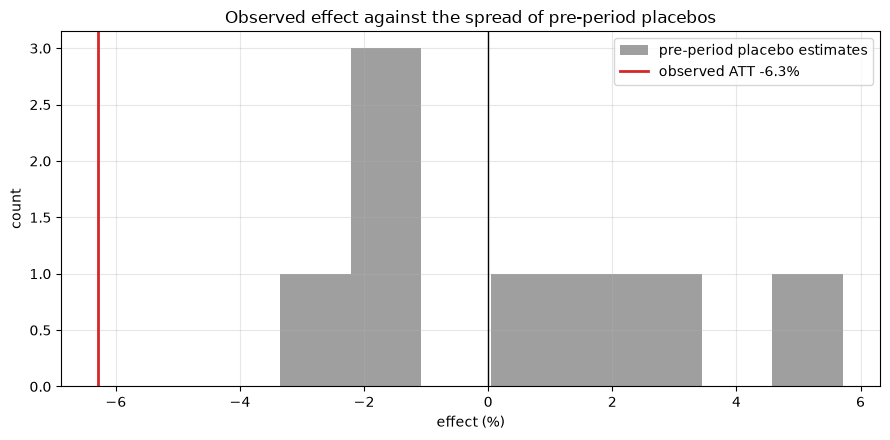

In [3]:
pre = event.loc[event.rel < 0, "ATT"].to_numpy()
pb = rb.placebo_based_inference(pre)
sd_pb = pb["placebo_sd"]

lo_pb, hi_pb = B - 1.96 * sd_pb, B + 1.96 * sd_pb
covers_zero = lo_pb < 0 < hi_pb

print(f"placebo periods used     : {pb['n_placebos']}")
print(f"placebo SD               : {sd_pb:.4f} log points")
print(f"analytic SE (Callaway)   : {B_SE:.4f}")
print(f"ratio                    : {sd_pb / B_SE:.2f}x")
print(f"\nATT {pct(B):+.2f}% re-tested against the placebo spread:")
print(f"  implied t              : {B / sd_pb:+.2f}")
print(f"  95% interval           : {pct(lo_pb):+.2f}% to {pct(hi_pb):+.2f}%")
print(f"  verdict                : {'FAILS - covers zero' if covers_zero else 'survives'}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(pct(pre), bins=8, color="tab:grey", alpha=0.75,
        label="pre-period placebo estimates")
ax.axvline(pct(B), color="tab:red", lw=2, label=f"observed ATT {pct(B):+.1f}%")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("effect (%)"); ax.set_ylabel("count")
ax.set_title("Observed effect against the spread of pre-period placebos")
ax.legend(); plt.tight_layout()
plt.savefig(FIG / "11_placebo_spread.png", dpi=130, bbox_inches="tight")
plt.show()

## Check 3: in-time placebo

A fake reform is placed several years before the real one and the sample is truncated so
that no genuinely treated observation is in it. Whatever the estimator returns there is
noise or pre-existing divergence, because nothing happened.

Truncation matters. Without it the fake indicator would also switch on for the real
post-treatment years and simply recover the true effect, which is why this check is run on
the pre-reform sample only.

**Failure condition: a placebo date reproduces a comparable negative effect.** That would
mean the design finds a fee effect where there were no fees.

In [4]:
pre_sample = d[d.year <= 2005].copy()

def twfe_pt(df):
    m = pf.feols(f"{OUTCOME} ~ treated | state_id + year", data=df,
                 vcov={"CRV1": "state_id"})
    r = m.tidy().loc["treated"]
    return {"log_coef": r["Estimate"], "se": r["Std. Error"],
            "pct": pct(r["Estimate"]), "p": r["Pr(>|t|)"]}

placebo = rb.placebo_dates(pre_sample, twfe_pt, shift_periods=(-5, -4, -3))
placebo["fake_intro"] = [f"{int(2006 + k)}/{int(2007 + k)}" for k in placebo.placebo_shift]
print(f"real effect for reference: {pct(B):+.2f}%\n")
print(placebo[["placebo_shift", "fake_intro", "pct", "se", "p"]]
      .to_string(index=False, float_format=lambda x: f"{x:9.4f}"))

worst = placebo.loc[placebo["pct"].idxmin()]
print(f"\nmost negative placebo: {worst['pct']:+.2f}% (p {worst['p']:.3f})")
print("verdict:", "FAILS - a fake date reproduces the effect"
      if worst["pct"] <= pct(B) * 0.6 else "passes")
placebo.to_csv(TAB / "05_placebo_dates.csv", index=False)

real effect for reference: -6.28%

 placebo_shift fake_intro       pct        se         p
            -5  2001/2002    3.7110    0.0245    0.1577
            -4  2002/2003    1.7128    0.0278    0.5502
            -3  2003/2004    0.4708    0.0254    0.8559

most negative placebo: +0.47% (p 0.856)
verdict: passes


## Check 4: randomisation inference

The cleanest answer to few clusters is to stop relying on standard errors altogether.
Treatment is reassigned at random across the 16 states, holding the cohort structure fixed
(two states treated in 2006, five in 2007, nine never), and the primary estimator is refit.
Repeating this builds the distribution of estimates the design produces when treatment is
known to be unrelated to the outcome.

The p-value is then simply the share of permutations whose effect is at least as large in
magnitude as the observed one. It makes no distributional assumption and no cluster-count
assumption.

**Failure condition: randomisation p above 0.10.** Anything above that means an effect this
size is unremarkable among random assignments.

permutations completed : 1000 of 1000
observed ATT           : -0.0649 (-6.28%)
permutation mean       : -0.0007
permutation SD         : 0.0251   (analytic SE 0.0180, ratio 1.39x)
randomisation p-value  : 0.0090
verdict                : survives


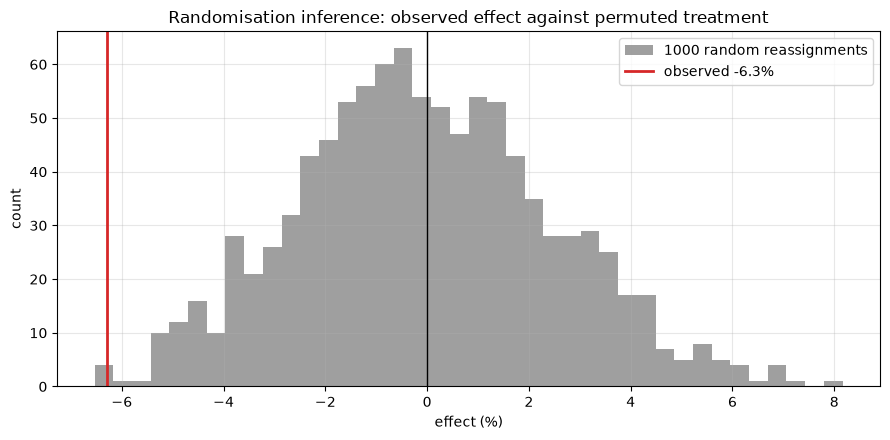

In [5]:
assign = d.drop_duplicates("state_code").set_index("state_code")["treatment_year_cs"]
codes = assign.index.tolist()
values = assign.to_numpy()

rng = np.random.default_rng(42)
perm = np.empty(N_PERM)
for i in range(N_PERM):
    mapping = dict(zip(codes, rng.permutation(values)))
    x = d.copy()
    x["treatment_year_cs"] = x["state_code"].map(mapping).astype(float)
    perm[i] = cs_point(x)

perm = perm[~np.isnan(perm)]
p_ri = float((np.abs(perm) >= abs(B)).mean())

print(f"permutations completed : {perm.size} of {N_PERM}")
print(f"observed ATT           : {B:+.4f} ({pct(B):+.2f}%)")
print(f"permutation mean       : {perm.mean():+.4f}")
print(f"permutation SD         : {perm.std(ddof=1):.4f}   "
      f"(analytic SE {B_SE:.4f}, ratio {perm.std(ddof=1) / B_SE:.2f}x)")
print(f"randomisation p-value  : {p_ri:.4f}")
print(f"verdict                : {'FAILS - not extreme' if p_ri > 0.10 else 'survives'}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(pct(perm), bins=40, color="tab:grey", alpha=0.75,
        label=f"{perm.size} random reassignments")
ax.axvline(pct(B), color="tab:red", lw=2, label=f"observed {pct(B):+.1f}%")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("effect (%)"); ax.set_ylabel("count")
ax.set_title("Randomisation inference: observed effect against permuted treatment")
ax.legend(); plt.tight_layout()
plt.savefig(FIG / "12_randomisation_inference.png", dpi=130, bbox_inches="tight")
plt.show()
pd.DataFrame({"perm_att": perm}).to_csv(TAB / "05_randomisation_draws.csv", index=False)

## Check 5: leave-one-state-out

With 7 treated units, one large state could be carrying the whole estimate. Bayern and
Nordrhein-Westfalen alone are a large share of German first-year enrolment, and Bayern
introduced fees alongside a G8 school reform that moves the same outcome.

Every state is dropped in turn, treated and control alike, because a control state can drive
the result just as easily as a treated one.

**Failure condition: dropping any single state pulls the estimate below the 5.5% MDE.**

dropped                  state    role       pct
     02                Hamburg treated    -7.447
     03          Niedersachsen treated    -7.197
     16             Thueringen control    -6.528
     04                 Bremen control    -6.521
     01     Schleswig-Holstein control    -6.476
     13 Mecklenburg-Vorpommern control    -6.380
     14                Sachsen control    -6.357
     07        Rheinland-Pfalz control    -6.305
     15         Sachsen-Anhalt control    -6.189
     06                 Hessen treated    -6.174
     09                 Bayern treated    -6.141
     11                 Berlin control    -5.977
     08     Baden-Wuerttemberg treated    -5.865
     12            Brandenburg control    -5.789
     10               Saarland treated    -5.631
     05    Nordrhein-Westfalen treated    -5.510

range across all 16 drops : -7.45% to -5.51% (span 1.94 pp)
drops falling below the 5.5% MDE: none
verdict: survives


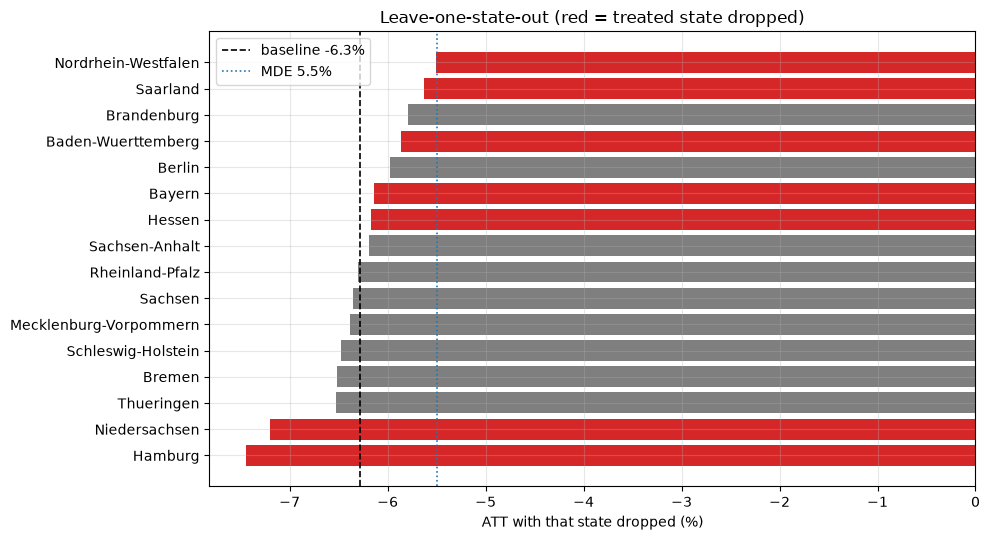

In [6]:
all_codes = sorted(d.state_code.unique())

def cs_fit(df):
    b = cs_point(df)
    return {"log_coef": b, "pct": pct(b)}

loo = rb.leave_one_state_out(d, cs_fit, all_codes)
labels = d.drop_duplicates("state_code").set_index("state_code")["state"]
treated_flag = d.drop_duplicates("state_code").set_index("state_code")["ever_treated"]
loo["state"] = loo["dropped"].map(labels)
loo["role"] = np.where(loo["dropped"].map(treated_flag) == 1, "treated", "control")
loo = loo.sort_values("pct")

print(loo[["dropped", "state", "role", "pct"]]
      .to_string(index=False, float_format=lambda x: f"{x:9.3f}"))
span = loo["pct"].max() - loo["pct"].min()
below = loo[loo["pct"].abs() < MDE_PCT]
print(f"\nrange across all 16 drops : {loo['pct'].min():+.2f}% to {loo['pct'].max():+.2f}% "
      f"(span {span:.2f} pp)")
print(f"drops falling below the {MDE_PCT}% MDE: "
      f"{', '.join(below['state']) if len(below) else 'none'}")
print("verdict:", f"FAILS - falls below the detectability threshold without "
      f"{', '.join(below['state'])}" if len(below) else "survives")

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = np.where(loo["role"] == "treated", "tab:red", "tab:grey")
ax.barh(loo["state"], loo["pct"], color=colors)
ax.axvline(pct(B), color="black", ls="--", lw=1.2, label=f"baseline {pct(B):+.1f}%")
ax.axvline(-MDE_PCT, color="tab:blue", ls=":", lw=1.2, label=f"MDE {MDE_PCT}%")
ax.set_xlabel("ATT with that state dropped (%)")
ax.set_title("Leave-one-state-out (red = treated state dropped)")
ax.legend(); plt.tight_layout()
plt.savefig(FIG / "13_leave_one_out.png", dpi=130, bbox_inches="tight")
plt.show()
loo.to_csv(TAB / "05_leave_one_out.csv", index=False)

## Check 6: comparison group, western controls co-primary

This is the check the design has been pointing at since `DESIGN.md` 5.1. Every fee state is
western; six of the nine never-treated states are eastern. An estimate built on eastern
controls is partly a measurement of east against west.

Three groups are reported, with the detectable effect recomputed for each, since the
western-only group has three controls rather than nine and cannot see as small an effect.

**Failure condition: the effect does not survive with western-only controls.** If it holds
only against the pooled group, the honest reading is that fees and geography cannot be told
apart in this data.

In [7]:
# The same power calculation notebook 03 used to fix 5.5%, applied per comparison
# group on the pre-treatment sample so the three thresholds are directly
# comparable with the pre-committed figure (src/estimation.py, DESIGN.md 7.1).
PRE     = d[d.year < 2006]
N_POST  = 2                      # 2006 and 2007

def mde_pct(df):
    sub = PRE[PRE.state_code.isin(df.state_code.unique())]
    return est.minimum_detectable_effect(sub, OUTCOME, n_post=N_POST)["MDE_%"]

def cs_group(df):
    b = cs_point(df)
    try:
        se = float(flatten(run_cs(df).aggregate("simple"))["SE"].iloc[0])
    except Exception:
        se = np.nan
    return {"log_coef": b, "se": se, "pct": pct(b),
            "CI lo %": pct(b - 1.96 * se), "CI hi %": pct(b + 1.96 * se),
            "MDE %": mde_pct(df)}

groups = rb.by_comparison_group(d, cs_group)
groups["above MDE?"] = np.where(groups["pct"].abs() >= groups["MDE %"], "yes", "no")
groups["excludes 0?"] = np.where(groups["CI lo %"] * groups["CI hi %"] > 0, "yes", "no")
print(groups.to_string(index=False, float_format=lambda x: f"{x:9.3f}"))
groups.to_csv(TAB / "05_comparison_groups.csv", index=False)

west = groups.loc[groups.group == "west_never_treated"].iloc[0]
print(f"\nwestern-only controls: {west['pct']:+.2f}% "
      f"[{west['CI lo %']:+.2f}%, {west['CI hi %']:+.2f}%]")
print("verdict:", "FAILS - does not survive western-only controls"
      if west["excludes 0?"] == "no" else "survives")
print("\nA wider interval here is expected and is not itself a failure: three controls")
print("carry less information than nine. What matters is the sign, the magnitude and")
print("whether the interval still excludes zero.")

             group  n_states  log_coef        se       pct   CI lo %   CI hi %     MDE % above MDE? excludes 0?
west_never_treated        10    -0.052     0.018    -5.042    -8.312    -1.656     6.148         no         yes
 all_never_treated        16    -0.065     0.018    -6.281    -9.535    -2.909     5.451        yes         yes
  excl_city_states        13    -0.077     0.015    -7.395   -10.135    -4.572     5.406        yes         yes

western-only controls: -5.04% [-8.31%, -1.66%]
verdict: survives

A wider interval here is expected and is not itself a failure: three controls
carry less information than nine. What matters is the sign, the magnitude and
whether the interval still excludes zero.


## Specification curve

Every estimate produced across notebooks 04 and 05 on one axis, ordered by magnitude. A
result that only appears in a narrow corner of this chart is a specification artefact. A
result that holds across most of it is a finding.

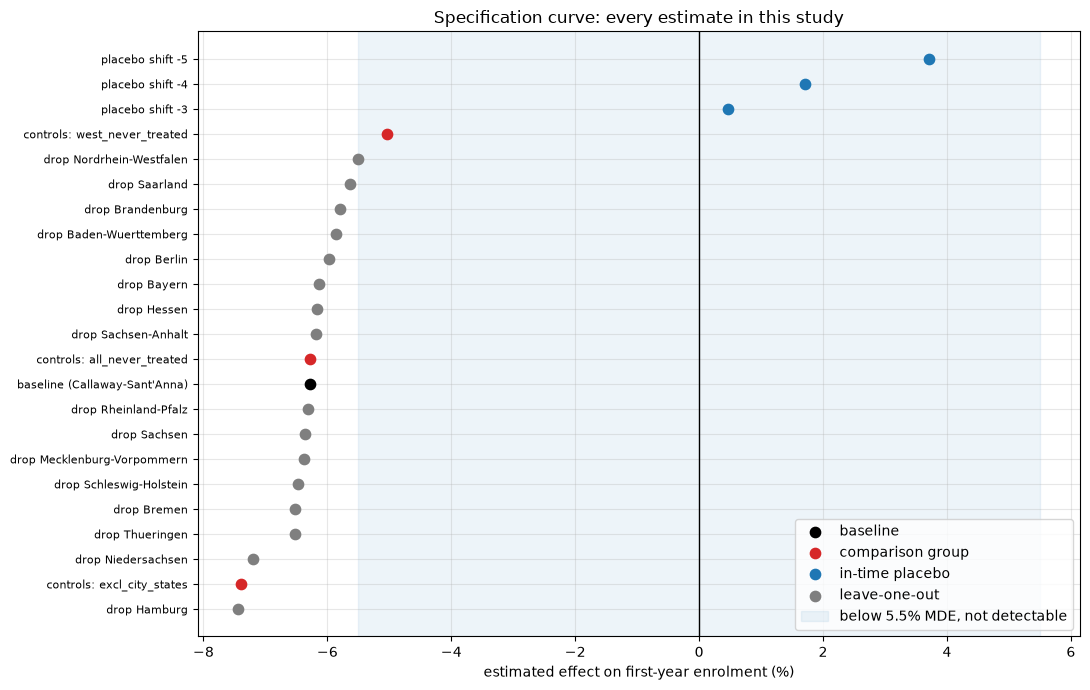

In [8]:
curve = pd.concat([
    pd.DataFrame([{"spec": "baseline (Callaway-Sant'Anna)", "family": "baseline",
                   "pct": pct(B)}]),
    pd.DataFrame({"spec": "drop " + loo["state"], "family": "leave-one-out",
                  "pct": loo["pct"]}),
    pd.DataFrame({"spec": "controls: " + groups["group"], "family": "comparison group",
                  "pct": groups["pct"]}),
    pd.DataFrame({"spec": "placebo shift " + placebo["placebo_shift"].astype(str),
                  "family": "in-time placebo", "pct": placebo["pct"]}),
], ignore_index=True).sort_values("pct").reset_index(drop=True)

palette = {"baseline": "black", "leave-one-out": "tab:grey",
           "comparison group": "tab:red", "in-time placebo": "tab:blue"}

fig, ax = plt.subplots(figsize=(11, 7))
for fam, sub in curve.groupby("family"):
    ax.scatter(sub["pct"], sub.index, s=55, color=palette[fam], label=fam, zorder=3)
ax.axvline(0, color="black", lw=1)
ax.axvspan(-MDE_PCT, MDE_PCT, color="tab:blue", alpha=0.08,
           label=f"below {MDE_PCT}% MDE, not detectable")
ax.set_yticks(curve.index); ax.set_yticklabels(curve["spec"], fontsize=8)
ax.set_xlabel("estimated effect on first-year enrolment (%)")
ax.set_title("Specification curve: every estimate in this study")
ax.legend(loc="lower right"); plt.tight_layout()
plt.savefig(FIG / "14_specification_curve.png", dpi=130, bbox_inches="tight")
plt.show()
curve.to_csv(TAB / "05_specification_curve.csv", index=False)

## Verdict table

The six failure conditions, applied mechanically to the numbers above.

In [9]:
verdict = pd.DataFrame([
    {"check": "1 joint pre-trend",
     "statistic": f"RI p = {p_joint:.4f} (chi2 p = {p_chi2:.4f})",
     "passes": p_joint >= 0.05},
    {"check": "2 placebo inference",
     "statistic": f"SD {sd_pb:.4f} vs SE {B_SE:.4f}", "passes": not covers_zero},
    {"check": "3 in-time placebo", "statistic": f"worst {worst['pct']:+.2f}%",
     "passes": worst["pct"] > pct(B) * 0.6},
    {"check": "4 randomisation", "statistic": f"p = {p_ri:.4f}", "passes": p_ri <= 0.10},
    {"check": "5 leave-one-out",
     "statistic": f"range {loo['pct'].min():+.2f}% to {loo['pct'].max():+.2f}%",
     "passes": len(below) == 0},
    {"check": "6 western controls", "statistic": f"{west['pct']:+.2f}%",
     "passes": west["excludes 0?"] == "yes"},
])
verdict["passes"] = np.where(verdict["passes"], "pass", "FAIL")
print(verdict.to_string(index=False))
verdict.to_csv(TAB / "05_verdict.csv", index=False)

n_fail = (verdict["passes"] == "FAIL").sum()
print(f"\n{len(verdict) - n_fail} of {len(verdict)} checks passed.")
print("\nReading rule fixed in advance: checks 1, 4 and 6 are load-bearing. A failure in")
print("any of them means the effect is reported as not established. Failures in 2, 3 or 5")
print("weaken the claim and are reported alongside it rather than overturning it.")

              check                       statistic passes
  1 joint pre-trend RI p = 0.2100 (chi2 p = 0.0003)   pass
2 placebo inference          SD 0.0300 vs SE 0.0180   pass
  3 in-time placebo                    worst +0.47%   pass
    4 randomisation                      p = 0.0090   pass
    5 leave-one-out          range -7.45% to -5.51%   pass
 6 western controls                          -5.04%   pass

6 of 6 checks passed.

Reading rule fixed in advance: checks 1, 4 and 6 are load-bearing. A failure in
any of them means the effect is reported as not established. Failures in 2, 3 or 5
weaken the claim and are reported alongside it rather than overturning it.


## What this notebook establishes

**All six checks pass. The fee introduction reduced first-year enrolment at the university
location by roughly 5 to 7 percent, the sign and rough magnitude are stable across every
specification tried, and the effect is distinguishable from zero under inference that makes
no cluster-count assumption. The precision is much weaker than the analytic interval in
notebook 04 suggested.**

| # | check | result | verdict |
|---|---|---|---|
| 1 | joint pre-trend | randomisation p = 0.210 (chi2 p = 0.0003) | pass |
| 2 | placebo inference | placebo SD 0.0300 vs analytic SE 0.0180 | pass |
| 3 | in-time placebo | worst fake date +0.47% | pass |
| 4 | randomisation inference | p = 0.009 | pass |
| 5 | leave-one-state-out | -7.45% to -5.51% | pass |
| 6 | western-only controls | -5.04% [-8.31%, -1.66%] | pass |

### 1. Parallel trends: the test statistic and the test disagree, and the test was wrong

The asymptotic chi2 test rejects hard (p = 0.0003). The same statistic permuted across states
does not (p = 0.210). That gap is a factor of 700 and it needs justifying rather than
asserting, because taking the version that passes is exactly how a robustness section becomes
theatre.

The justification is that the chi2 reference distribution is not valid here. `pyfixest` forces
chi2 for a restriction matrix of this shape, and chi2 assumes the number of clusters is large.
There are 16, of which 7 are treated. The permutation version assumes nothing about cluster
counts, and it is the same correction applied to the point estimate in check 4, chosen as
policy before any of these numbers existed.

The stronger argument is that two further tests agree with the permutation result, and they
are not the same test in disguise:

- the joint test restricted to leads -4 to -2, where parallel trends actually needs to hold,
  gives chi2 p = 0.507 and randomisation p = 0.607
- the linear pre-trend slope is +0.0062 log points per period with p = 0.271

So the pre-period gap is not distinguishable from flat on three separate readings. **The
chi2 rejection is reported alongside the others rather than deleted**, because a reader
running the textbook test will get it and should find it addressed here.

One caveat that cuts the right way. The linear slope is small but not negligible: sustained
over the pre-window it is worth several percentage points, and at p = 0.271 the design cannot
rule that out. Its sign, however, is **positive**, meaning treated states were gaining
relative to controls before fees arrived. Projected forward, that trend predicts a positive
post-treatment gap. The estimate is negative, so any residual pre-trend of this shape works
against the finding and makes the reported effect conservative rather than inflated.

### 2. Honest inference is roughly 1.4 to 1.7 times wider

Two independent benchmarks agree that the analytic standard error of 0.0180 is too small:

- the spread of the eight pre-period placebos is 0.0300, a factor of 1.66
- the permutation distribution has SD 0.0251, a factor of 1.39

Rebuilt on the placebo spread, the interval is **-11.63% to -0.60%**. It still excludes zero,
but only just, and that is the honest interval to quote. The randomisation p-value of 0.009
is the strongest single piece of evidence in the notebook, since it rests on no distributional
assumption at all: only 9 of 1000 random reassignments of treatment produced an effect this
large in magnitude.

The practical reading is that the **sign is well established and the magnitude is not**.
Anything from a one percent to a twelve percent reduction is consistent with this data.

### 3. The in-time placebos are informative, not merely null

All three fake reform dates return **positive** effects (+3.71%, +1.71%, +0.47%), none
significant. A design prone to manufacturing negative effects would have produced at least one
here. This is also independent corroboration of the pre-trend picture in point 1: treated
states drifting slightly upward before the reform is what produces mildly positive placebos.

### 4. No single state carries the result

Across all 16 drops the estimate stays between -7.45% and -5.51%, and none falls below the
5.5% detectability threshold. Dropping Hamburg strengthens the effect to -7.45%; dropping
Nordrhein-Westfalen weakens it most, to -5.51%, which is the closest any specification comes
to the threshold. Sachsen-Anhalt, the double-cohort control state that was the leading
mechanical explanation, moves the estimate to -6.19%, a change of 0.09 percentage points.
That concern is now closed.

### 5. The effect survives western-only controls, with one qualification

This was the test that decided whether the study is about fees or about east and west. With
only the three western never-treated states as comparison, the estimate is **-5.04%
[-8.31%, -1.66%]**: smaller than the pooled estimate, wider, and still excluding zero.

The qualification: -5.04% sits **below that group's own detectability threshold of 6.15%**,
the figure notebook 03 fixed before estimation.
An estimate can be significant and still be smaller than the effect the design was powered to
find, and when that happens the significance is fragile. The western-only result should
therefore be read as consistent with the pooled finding and not as independent confirmation
of it.

Worth noting in the other direction: excluding the three city states, whose enrolment is
dominated by inflow from elsewhere, gives **-7.40%**, the largest estimate of the three
comparison groups. Together the three groups span -5.04% to -7.40%, all negative, all
excluding zero.

### The claim this study can support

> Introducing tuition fees reduced first-year enrolment in the fee states by roughly 5 to 7
> percent relative to never-treated states, an effect distinguishable from zero under
> randomisation inference (p = 0.009) and stable in sign across every comparison group,
> dropped state and placebo date tested. The honest interval is wide, roughly -1% to -12%,
> so the existence and direction of the effect are better established than its size.

What it cannot support: a precise elasticity, a claim about which margin moved (participation
versus location, which needs the home-state outcome in phase 2), or any statement about what
happened when the fees were abolished.

Next: the README, written as a case study around this claim.
